# **Durability — SPAGHETTI PLOT & RUL ANALYSIS**

Loads the `(fck, rh, cov)`-fixed, time-swept GLD samples written by
[`05_generate_rul_dataset.ipynb`](05_generate_rul_dataset.ipynb) and:

1. draws the spaghetti plot of $g(t)$ = cover − carbonation depth (every Monte Carlo path, plus the mean);
2. turns each path into a failure time (`compute_rul_benchmark`, the first down-crossing of
   `threshold`, right-censored at the last time step if it never crosses) and reports the RUL
   distribution;
3. compares the $g$ distribution at a few chosen time steps; and
4. computes the **conditional** RUL given survival to a chosen time.

No emulator or NN calls here — this notebook only reads the `.pkl` written by stage 5 and plots.
Same figure conventions as [`01_generate_dataset_plot.ipynb`](01_generate_dataset_plot.ipynb).

## 1. Libraries

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd
import seaborn as sns

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import dill

from functions import compute_rul_benchmark

/home/casa-wand/steam2tb/2024-1_victor_hugo_renata_maria/.venv/lib/python3.11/site-packages/UQpy/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. Config

`n_latent_samples`, `fck_fixed`, `rh_fixed` and `cov_fixed` must match
[`05_generate_rul_dataset.ipynb`](05_generate_rul_dataset.ipynb) — together they name the file
being loaded.

`threshold` is the failure level on `g` = cover − carbonation depth, in millimetres (failure is
`g <=` `threshold`). A positive threshold expresses a preventive maintenance policy ("act while
there are still `threshold` mm of cover left before the carbonation front reaches the
reinforcement"); `threshold = 0` recovers the classical time-to-depassivation.

In [2]:
n_latent_samples = 2500   # must match stage 5 — it names the file being loaded
fck_fixed = 25.0          # must match stage 5
rh_fixed  = 55.0          # must match stage 5
cov_fixed = 25.0          # must match stage 5

threshold       = 5.0                      # mm of cover left — intervention margin
threshold_sweep = [0.0, 2.0, 5.0, 8.0, 12.0]   # policies compared in section 8

fig_size   = (6, 4.5)    # size of each individual figure, in inches
fig_format = 'png'       # format each figure is saved in ('pdf', 'png', ...)
fig_dpi    = 300         # resolution the figure is saved at (dots per inch)

label_fontsize = 14   # font size of the axis labels
tick_fontsize  = 12   # font size of the tick numbers

xlim = None   # e.g. (0, 100) to fix the time axis; None = auto-scaled to the data
ylim = None   # e.g. (-20, 30) to fix the g axis; None = auto-scaled to the data

n_paths_plotted = 300   # spaghetti lines drawn (all n_glam_samples would be far too many to render)
random_state    = 42

## 3. Load the RUL dataset

In [3]:
tag      = f'fck{fck_fixed:g}_rh{rh_fixed:g}_cov{cov_fixed:g}_durability'
pkl_name = f'{n_latent_samples}_rul_samples_{tag}'

with open(f'{n_latent_samples}_rul_lambdas_{tag}.pkl', 'rb') as f:
    lambda_df = dill.load(f)
with open(f'{pkl_name}.pkl', 'rb') as f:
    samples = dill.load(f)

times = lambda_df['Time (years)'].to_numpy()
print(f"Loaded samples: {samples.shape[0]} paths x {samples.shape[1]} time steps")
lambda_df

Loaded samples: 50000 paths x 20 time steps


,fck,rh,cov,Time (years),lambda 1,lambda 2,lambda 3,lambda 4
0,25.0,55.0,25.0,0.000000,24.809648,0.392594,0.198312,0.130039
1,25.0,55.0,25.0,5.263158,21.662538,0.351681,0.198312,0.130039
2,25.0,55.0,25.0,10.526316,18.534814,0.308140,0.198312,0.130039
3,25.0,55.0,25.0,15.789474,14.822707,0.290902,0.198312,0.130039
4,25.0,55.0,25.0,21.052632,10.811846,0.276716,0.198312,0.130039
5,25.0,55.0,25.0,26.315789,7.331875,0.261123,0.198312,0.130039
6,25.0,55.0,25.0,31.578947,5.300013,0.244408,0.198312,0.130039
7,25.0,55.0,25.0,36.842105,3.439305,0.232728,0.198312,0.130039
8,25.0,55.0,25.0,42.105263,2.265926,0.220727,0.198312,0.130039
9,25.0,55.0,25.0,47.368421,1.086627,0.210085,0.198312,0.130039


## 4. Spaghetti plot

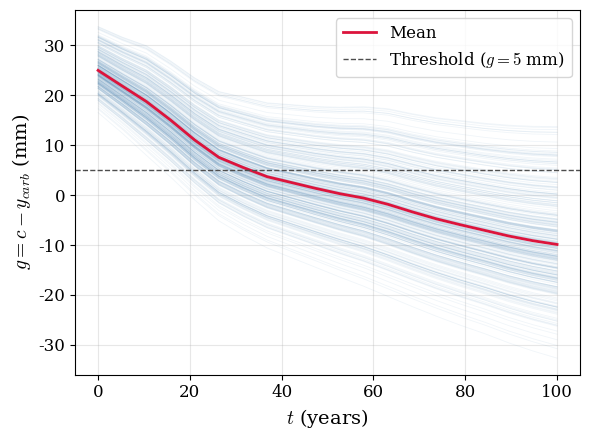

In [4]:
rng           = np.random.default_rng(random_state)
plotted_idx   = rng.choice(samples.shape[0], size=min(n_paths_plotted, samples.shape[0]), replace=False)

fig, ax = plt.subplots(figsize=fig_size)
for i in plotted_idx:
    ax.plot(times, samples[i], color='steelblue', alpha=0.08, linewidth=0.6)
ax.plot(times, samples.mean(axis=0), color='crimson', linewidth=2, label='Mean')
ax.axhline(threshold, color='0.3', linestyle='--', linewidth=1, label=f'Threshold ($g={threshold:g}$ mm)')

ax.set_xlabel('$t$ (years)', fontsize=label_fontsize)
ax.set_ylabel('$g = c - y_{carb}$ (mm)', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim is not None:
    ax.set_xlim(xlim)
if ylim is not None:
    ax.set_ylim(ylim)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_spaghetti.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 4.1 Mesmo gráfico, em português

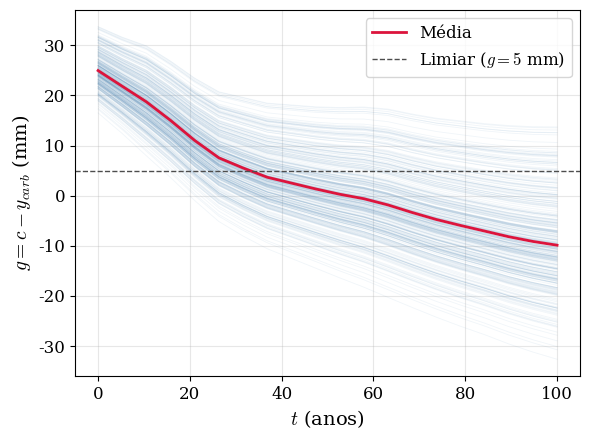

In [5]:
fig, ax = plt.subplots(figsize=fig_size)
for i in plotted_idx:
    ax.plot(times, samples[i], color='steelblue', alpha=0.08, linewidth=0.6)
ax.plot(times, samples.mean(axis=0), color='crimson', linewidth=2, label='Média')
ax.axhline(threshold, color='0.3', linestyle='--', linewidth=1, label=f'Limiar ($g={threshold:g}$ mm)')

ax.set_xlabel('$t$ (anos)', fontsize=label_fontsize)
ax.set_ylabel('$g = c - y_{carb}$ (mm)', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim is not None:
    ax.set_xlim(xlim)
if ylim is not None:
    ax.set_ylim(ylim)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_spaghetti_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

## 5. RUL — time to failure

`compute_rul_benchmark` (fully generic — reused as-is, no durability-specific logic needed) finds,
for every Monte Carlo path, the first time $g$ drops to or below `threshold` (linear interpolation
between the two straddling time steps). A path that never crosses is right-censored at
`times[-1]`.

In [6]:
failure_times = compute_rul_benchmark(samples, times, threshold=threshold)
n_censored    = int(np.sum(failure_times == times[-1]))

print(f"Failure times: {len(failure_times)} paths ({n_censored} right-censored at t={times[-1]:.1f})")
print(f"  Mean:   {failure_times.mean():.2f}")
print(f"  Median: {np.median(failure_times):.2f}")
print(f"  Std:    {failure_times.std():.2f}")
print(f"  P5:     {np.percentile(failure_times, 5):.2f}")
print(f"  P95:    {np.percentile(failure_times, 95):.2f}")

Failure times: 50000 paths (3279 right-censored at t=100.0)
  Mean:   41.70
  Median: 32.74
  Std:    23.52
  P5:     18.46
  P95:    100.00


### 5.1 RUL probability density

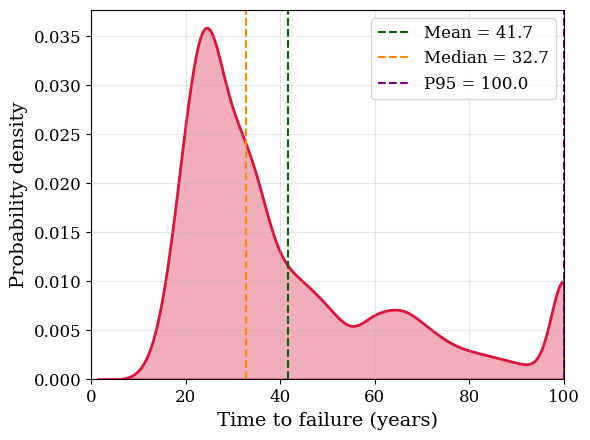

In [7]:
fig, ax = plt.subplots(figsize=fig_size)
sns.kdeplot(failure_times, ax=ax, color='crimson', linewidth=2, fill=True, alpha=0.35, clip=(0, times[-1]))

for value, label, color in [(failure_times.mean(), 'Mean', 'darkgreen'),
                             (np.median(failure_times), 'Median', 'darkorange'),
                             (np.percentile(failure_times, 95), 'P95', 'purple')]:
    ax.axvline(value, color=color, linestyle='--', linewidth=1.5, label=f'{label} = {value:.1f}')

ax.set_xlim(0, failure_times.max())
ax.set_xlabel('Time to failure (years)', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_rul_pdf.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 5.2 Mesmo gráfico, em português

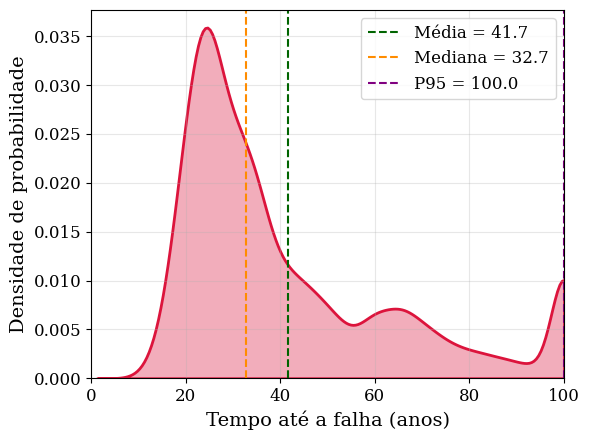

In [8]:
fig, ax = plt.subplots(figsize=fig_size)
sns.kdeplot(failure_times, ax=ax, color='crimson', linewidth=2, fill=True, alpha=0.35, clip=(0, times[-1]))

for value, label, color in [(failure_times.mean(), 'Média', 'darkgreen'),
                             (np.median(failure_times), 'Mediana', 'darkorange'),
                             (np.percentile(failure_times, 95), 'P95', 'purple')]:
    ax.axvline(value, color=color, linestyle='--', linewidth=1.5, label=f'{label} = {value:.1f}')

ax.set_xlim(0, failure_times.max())
ax.set_xlabel('Tempo até a falha (anos)', fontsize=label_fontsize)
ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_rul_pdf_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

## 6. $g$ distribution at a few time steps

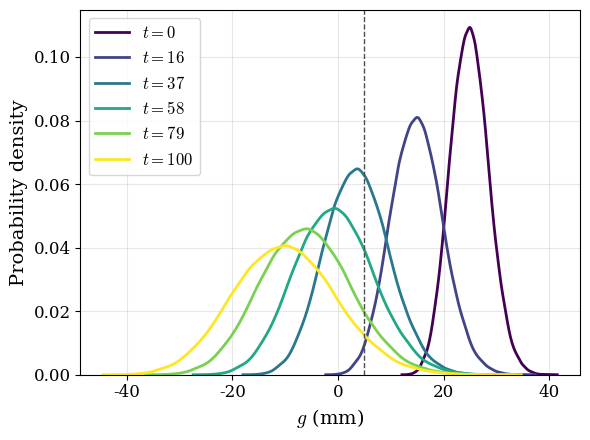

In [9]:
time_indices = np.linspace(0, len(times) - 1, min(6, len(times)), dtype=int)

fig, ax = plt.subplots(figsize=fig_size)
colors = plt.cm.viridis(np.linspace(0, 1, len(time_indices)))
for idx, color in zip(time_indices, colors):
    sns.kdeplot(samples[:, idx], ax=ax, color=color, linewidth=2, label=f'$t={times[idx]:.0f}$')

ax.axvline(threshold, color='0.3', linestyle='--', linewidth=1)
ax.set_xlabel('$g$ (mm)', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_g_pdfs.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 6.1 Mesmo gráfico, em português

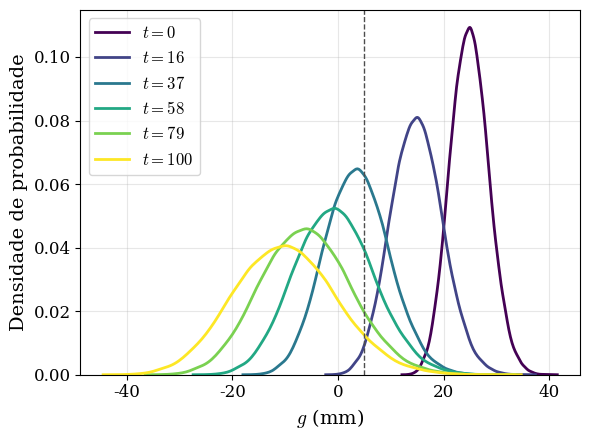

In [10]:
fig, ax = plt.subplots(figsize=fig_size)
colors = plt.cm.viridis(np.linspace(0, 1, len(time_indices)))
for idx, color in zip(time_indices, colors):
    sns.kdeplot(samples[:, idx], ax=ax, color=color, linewidth=2, label=f'$t={times[idx]:.0f}$')

ax.axvline(threshold, color='0.3', linestyle='--', linewidth=1)
ax.set_xlabel('$g$ (mm)', fontsize=label_fontsize)
ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_g_pdfs_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

## 7. Conditional RUL — given survival to a chosen time

Restricts to paths that are still above `threshold` at `time_query`, and reports **RUL from
`time_query`** (not from $t=0$) for those survivors.

Survivors at t=25.0: 36509 / 50000


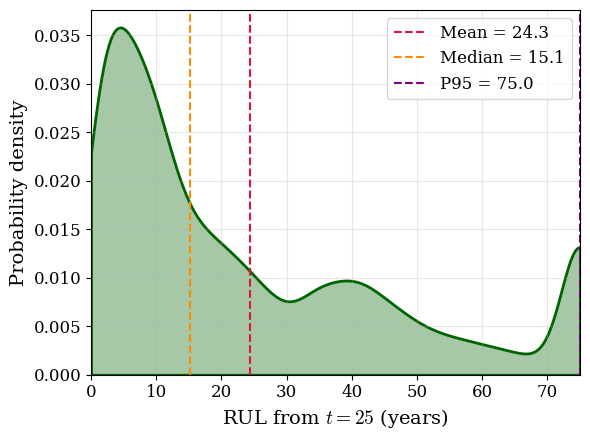


Conditional RUL from t=25.0:
  Mean:   24.32
  Median: 15.15
  P95:    75.00


In [11]:
time_query = 25.0   # condition on survival up to this time (interpolated, need not sit on the time grid)

idx_hi     = int(np.clip(np.searchsorted(times, time_query, side='right'), 1, len(times) - 1))
idx_lo     = idx_hi - 1
frac       = (time_query - times[idx_lo]) / (times[idx_hi] - times[idx_lo])
g_at_query = samples[:, idx_lo] + frac * (samples[:, idx_hi] - samples[:, idx_lo])

survivors_mask = g_at_query > threshold
print(f"Survivors at t={time_query:.1f}: {survivors_mask.sum()} / {len(survivors_mask)}")

if survivors_mask.sum() == 0:
    print("No surviving paths at this time — pick an earlier time_query.")
else:
    failure_times_survivors = compute_rul_benchmark(samples[survivors_mask], times, threshold=threshold)
    conditional_rul = failure_times_survivors[failure_times_survivors > time_query] - time_query
    rul_horizon = times[-1] - time_query   # longest RUL reachable within the simulated horizon

    fig, ax = plt.subplots(figsize=fig_size)
    sns.kdeplot(conditional_rul, ax=ax, color='darkgreen', linewidth=2, fill=True, alpha=0.35, clip=(0, rul_horizon))

    for value, label, color in [(conditional_rul.mean(), 'Mean', 'crimson'),
                                 (np.median(conditional_rul), 'Median', 'darkorange'),
                                 (np.percentile(conditional_rul, 95), 'P95', 'purple')]:
        ax.axvline(value, color=color, linestyle='--', linewidth=1.5, label=f'{label} = {value:.1f}')

    ax.set_xlim(0, conditional_rul.max())
    ax.set_xlabel(f'RUL from $t={time_query:.0f}$ (years)', fontsize=label_fontsize)
    ax.set_ylabel('Probability density', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.legend(fontsize=tick_fontsize)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fig.savefig(f'{pkl_name}_conditional_rul_t{time_query:.0f}.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    plt.show()

    print(f"\nConditional RUL from t={time_query:.1f}:")
    print(f"  Mean:   {conditional_rul.mean():.2f}")
    print(f"  Median: {np.median(conditional_rul):.2f}")
    print(f"  P95:    {np.percentile(conditional_rul, 95):.2f}")

### 7.1 Mesmo gráfico, em português

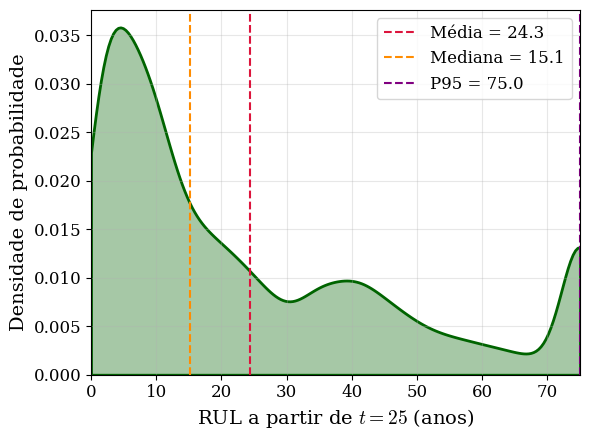

In [12]:
if survivors_mask.sum() == 0:
    print("Nenhuma trajetória sobrevivente nesse instante — escolha um time_query mais cedo.")
else:
    fig, ax = plt.subplots(figsize=fig_size)
    sns.kdeplot(conditional_rul, ax=ax, color='darkgreen', linewidth=2, fill=True, alpha=0.35, clip=(0, rul_horizon))

    for value, label, color in [(conditional_rul.mean(), 'Média', 'crimson'),
                                 (np.median(conditional_rul), 'Mediana', 'darkorange'),
                                 (np.percentile(conditional_rul, 95), 'P95', 'purple')]:
        ax.axvline(value, color=color, linestyle='--', linewidth=1.5, label=f'{label} = {value:.1f}')

    ax.set_xlim(0, conditional_rul.max())
    ax.set_xlabel(f'RUL a partir de $t={time_query:.0f}$ (anos)', fontsize=label_fontsize)
    ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.legend(fontsize=tick_fontsize)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fig.savefig(f'{pkl_name}_conditional_rul_t{time_query:.0f}_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    plt.show()

## 8. Threshold sweep — remaining life as a function of the maintenance policy

The threshold is a **decision variable**, not a property of the structure. Sweeping it turns a
single RUL distribution into a family of them, one per policy.

In [13]:
rows = []
for g_lim in threshold_sweep:
    ft       = compute_rul_benchmark(samples, times, threshold=g_lim)
    censored = ft >= times[-1]
    reached  = ~censored
    rows.append({'threshold': g_lim,
                 'reached (%)': reached.mean() * 100,
                 'censored (%)': censored.mean() * 100,
                 'mean (years)': ft[reached].mean() if reached.any() else np.nan,
                 'P5 (years)': np.percentile(ft[reached], 5) if reached.any() else np.nan,
                 'P50 (years)': np.percentile(ft[reached], 50) if reached.any() else np.nan})

sweep = pd.DataFrame(rows)
print('Statistics are computed over the paths that actually reach the threshold;')
print('a large censored share means the horizon is too short to characterise that policy.\n')
sweep.round(2)

Statistics are computed over the paths that actually reach the threshold;
a large censored share means the horizon is too short to characterise that policy.



,threshold,reached (%),censored (%),mean (years),P5 (years),P50 (years)
0,0.0,84.69,15.31,50.49,24.31,46.89
1,2.0,88.87,11.13,45.34,21.80,39.83
2,5.0,93.44,6.56,37.61,18.29,31.40
3,8.0,96.39,3.61,30.37,14.72,25.11
4,12.0,98.54,1.46,22.09,9.66,19.50


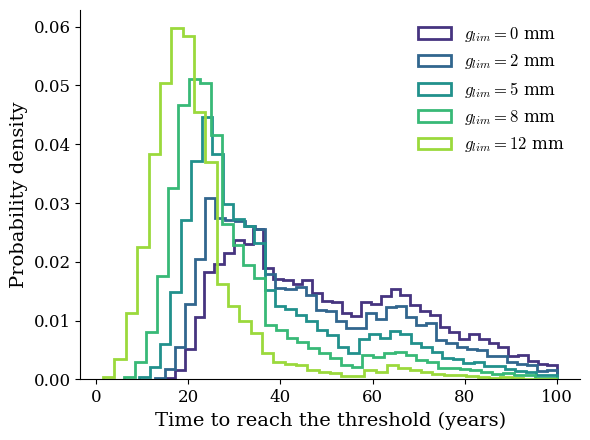

In [14]:
fig, ax = plt.subplots(figsize=fig_size)

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(threshold_sweep)))
for g_lim, color in zip(threshold_sweep, colors):
    ft      = compute_rul_benchmark(samples, times, threshold=g_lim)
    reached = ft < times[-1]
    if reached.sum() > 10:
        ax.hist(ft[reached], bins=40, density=True, histtype='step', linewidth=2.0,
                color=color, label=f'$g_{{lim}} = {g_lim:g}$ mm')

ax.set_xlabel('Time to reach the threshold (years)', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(labelsize=tick_fontsize)
ax.legend(frameon=False, fontsize=tick_fontsize)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
fig.tight_layout()
fig.savefig(f'z_rul_threshold_sweep_{tag}.{fig_format}', dpi=fig_dpi, bbox_inches='tight')
plt.show()